# EDA — MVTec AD: Gaussian Process Uncertainty for Novel Defect Type Detection
**Module:** ST7085CEM Advanced Machine Learning
**Group:** Ashish Jamarkattel | Manjil Karki | Sudip Adhikari
**Date:** 2026-08-25

---

## Figure Classification

| Label | Figures | Goes in report? |
|---|---|---|
| `[REPORT]` | R1 Sample Images, R2 Severity Distribution, R3 Dataset Table, R4 Fold Structure, R5 Severity Boxplots | **Yes — paper body** |
| `[APPENDIX]` | A1 Per-category histograms, A2 Log-transform validation | Appendix / supplementary |
| `[CODE ONLY]` | Heatmap, test-set sizes, image resolutions, coverage patterns | Not in report |

Increased word budget (~5500 words) allows all 5 report figures inline.
All figures saved to `results/figures/` at 200 DPI.


## 0. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from scipy import stats

warnings.filterwarnings("ignore")

BASE    = Path("/home/mjl/softwarica/production")
MVTEC   = BASE / "data/mvtec"
FIGURES = BASE / "results/figures"
DATA    = BASE / "data"
FIGURES.mkdir(parents=True, exist_ok=True)

ALL_CATS = sorted([d.name for d in MVTEC.iterdir() if d.is_dir()])
CATS     = [c for c in ALL_CATS if c != "toothbrush"]   # 14 usable

PALETTE  = sns.color_palette("tab20", 20)
CAT_CLR  = {c: PALETTE[i] for i, c in enumerate(CATS)}

plt.rcParams.update({
    "figure.dpi":       150,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.labelsize":   10,
    "legend.fontsize":  9,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
print("Setup complete.")
print(f"Usable categories ({len(CATS)}):", CATS)


Setup complete.
Usable categories (14): ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'transistor', 'wood', 'zipper']


## Build Manifest (`data/manifest.csv`)

Generates one row per image with severity computed from ground-truth masks.
This is the **Phase 0 exit criterion** from the execution plan.
`s = defect_pixels / total_pixels` — always > 0 for defective images, exactly 0 for normals.


In [2]:
def build_manifest():
    rows = []
    for cat in ALL_CATS:
        cp = MVTEC / cat
        # Normal training images
        for p in sorted((cp / "train" / "good").glob("*.png")):
            img = Image.open(p)
            rows.append(dict(category=cat, defect_type="good", split="train",
                             image_path=str(p), mask_path=None,
                             n_defect_px=0, n_total_px=img.width*img.height,
                             severity=0.0, width=img.width, height=img.height))
        # Test-good images
        for p in sorted((cp / "test" / "good").glob("*.png")):
            img = Image.open(p)
            rows.append(dict(category=cat, defect_type="good", split="test",
                             image_path=str(p), mask_path=None,
                             n_defect_px=0, n_total_px=img.width*img.height,
                             severity=0.0, width=img.width, height=img.height))
        # Defective test images
        for ddir in sorted((cp / "test").iterdir()):
            if ddir.name == "good":
                continue
            mdir = cp / "ground_truth" / ddir.name
            for p in sorted(ddir.glob("*.png")):
                mp   = mdir / (p.stem + "_mask.png")
                mask = np.array(Image.open(mp).convert("L"), dtype=np.uint8)
                nd   = int((mask > 0).sum())
                img  = Image.open(p)
                rows.append(dict(category=cat, defect_type=ddir.name, split="test",
                                 image_path=str(p), mask_path=str(mp),
                                 n_defect_px=nd, n_total_px=mask.size,
                                 severity=nd/mask.size,
                                 width=img.width, height=img.height))
    df = pd.DataFrame(rows)
    df.to_csv(DATA / "manifest.csv", index=False)
    return df

df = build_manifest()
print(f"Manifest: {len(df)} rows → {DATA/'manifest.csv'}")
print(df.groupby(["split",
    df.defect_type.eq("good").map({True:"normal", False:"defective"})
]).size().unstack(fill_value=0))


Manifest: 5354 rows → /home/mjl/softwarica/production/data/manifest.csv
defect_type  defective  normal
split                         
test              1258     467
train                0    3629


---
# REPORT FIGURES
The five cells below produce the figures that go **in the paper body**.

---
## [REPORT] R1 — Sample Images
**Paper section:** 2.2 Dataset
**Argument:** Shows visual diversity across categories and the pixel-precise masks that supply the severity target.
Defect regions are highlighted in red. Three categories chosen for maximum visual contrast.


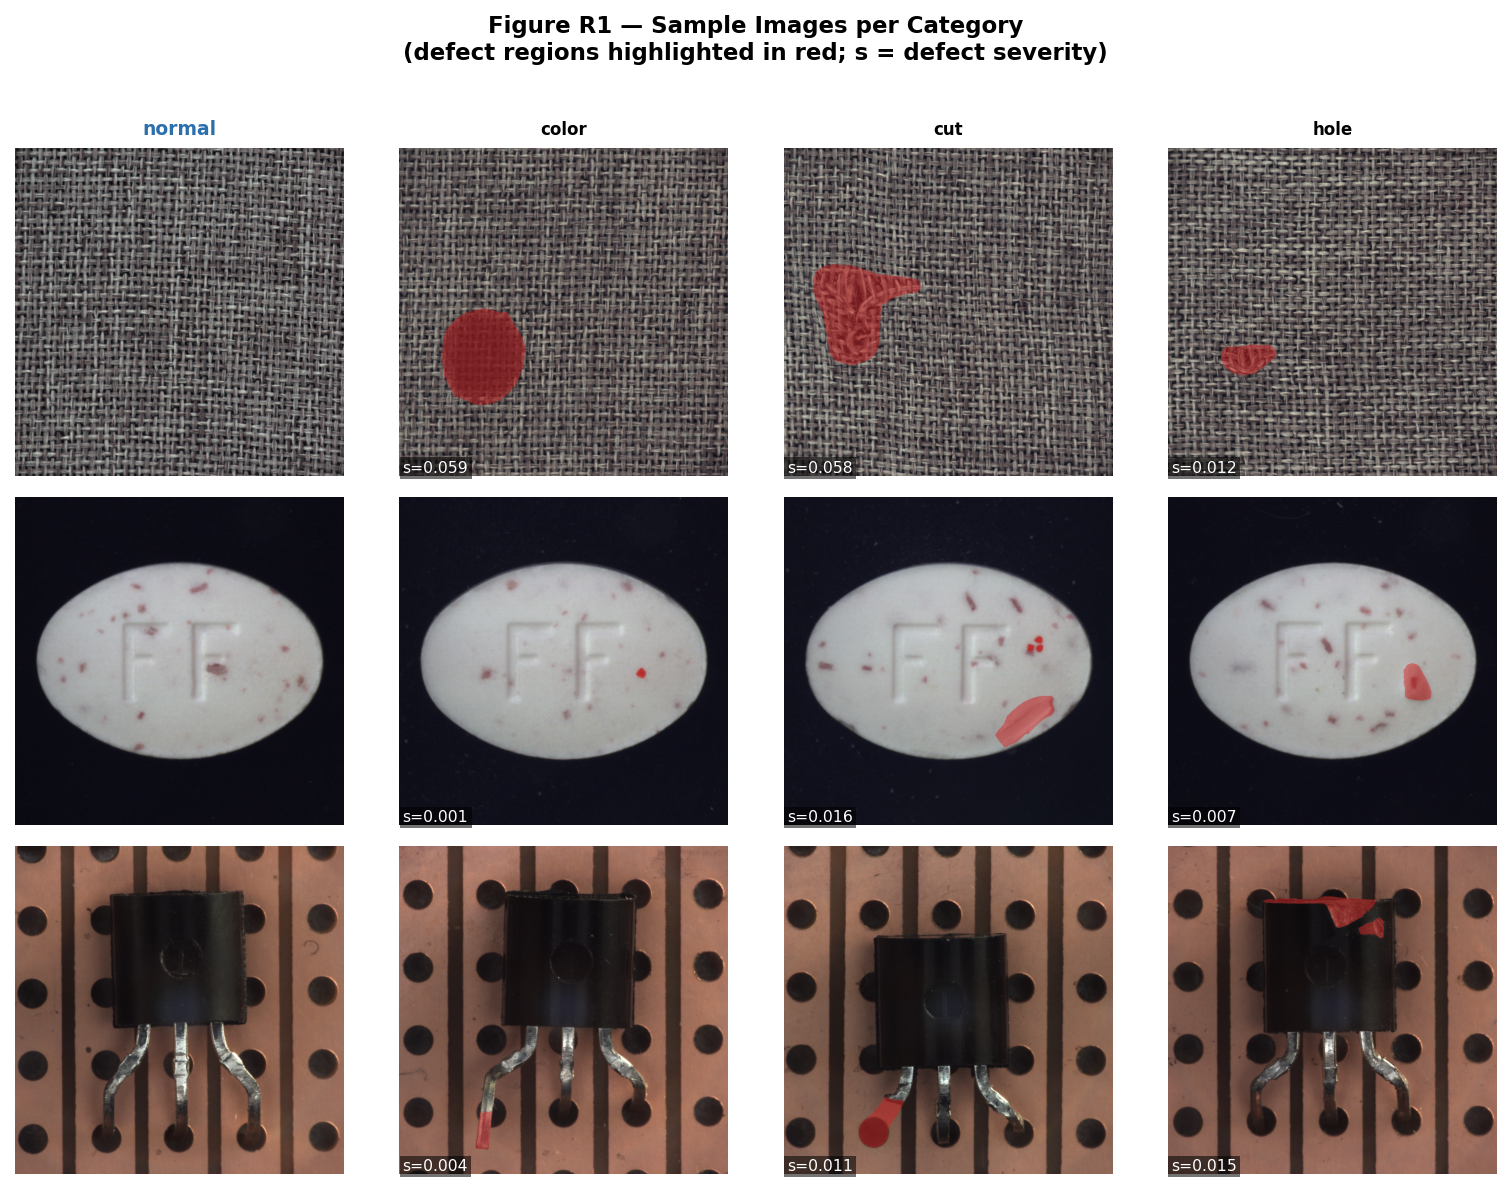

Saved → /home/mjl/softwarica/production/results/figures/R1_sample_images.png


In [3]:
def fig_R1_sample_images(df, cats=("carpet", "pill", "transistor"), n_defect=3):
    nrows, ncols = len(cats), 1 + n_defect
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.6, nrows*2.6))

    for r, cat in enumerate(cats):
        # Normal
        npath = df[(df.category==cat)&(df.split=="train")&(df.defect_type=="good")].image_path.iloc[0]
        axes[r,0].imshow(Image.open(npath).convert("RGB"))
        axes[r,0].set_ylabel(cat, fontsize=10, fontweight="bold",
                              rotation=0, labelpad=52, va="center")
        axes[r,0].axis("off")
        if r == 0:
            axes[r,0].set_title("normal", fontsize=9, fontweight="bold", color="#2c6fad")

        # Defective
        defs = df[(df.category==cat)&(df.split=="test")&(df.defect_type!="good")]
        for c, dtype in enumerate(sorted(defs.defect_type.unique())[:n_defect]):
            row = defs[defs.defect_type==dtype].iloc[0]
            img  = np.array(Image.open(row.image_path).convert("RGB"))
            mask = np.array(Image.open(row.mask_path).convert("L"))
            ov   = img.copy(); ov[mask>0] = [210, 35, 35]
            blend = (0.5*img + 0.5*ov).astype(np.uint8)
            ax = axes[r, c+1]
            ax.imshow(blend); ax.axis("off")
            if r == 0:
                ax.set_title(dtype, fontsize=8, fontweight="bold")
            ax.text(0.01, 0.01, f"s={row.severity:.3f}", transform=ax.transAxes,
                    fontsize=7.5, color="white",
                    bbox=dict(facecolor="black", alpha=0.55, pad=1.5, edgecolor="none"))

    fig.suptitle(
        "Figure R1 — Sample Images per Category\n"
        "(defect regions highlighted in red; s = defect severity)",
        fontsize=11, fontweight="bold", y=1.01)
    fig.tight_layout()
    path = FIGURES / "R1_sample_images.png"
    fig.savefig(path); plt.show()
    print(f"Saved → {path}")

fig_R1_sample_images(df)


---
## [REPORT] R2 — Severity Distribution
**Paper section:** 2.2 Dataset
**Argument (three panels):**
- *Left:* Full distribution is bimodal — large mass at s=0 (normals) plus a right-skewed tail (defectives). A Gaussian GP on raw s is misspecified.
- *Centre:* Defective-only raw severity across all categories — visually confirms right-skew and inter-category spread.
- *Right:* After log(s) the distribution is far more symmetric, supporting the Gaussian likelihood assumption for the GP.

This single figure justifies (a) fitting the GP only on defective images and (b) using log(s) as the target.


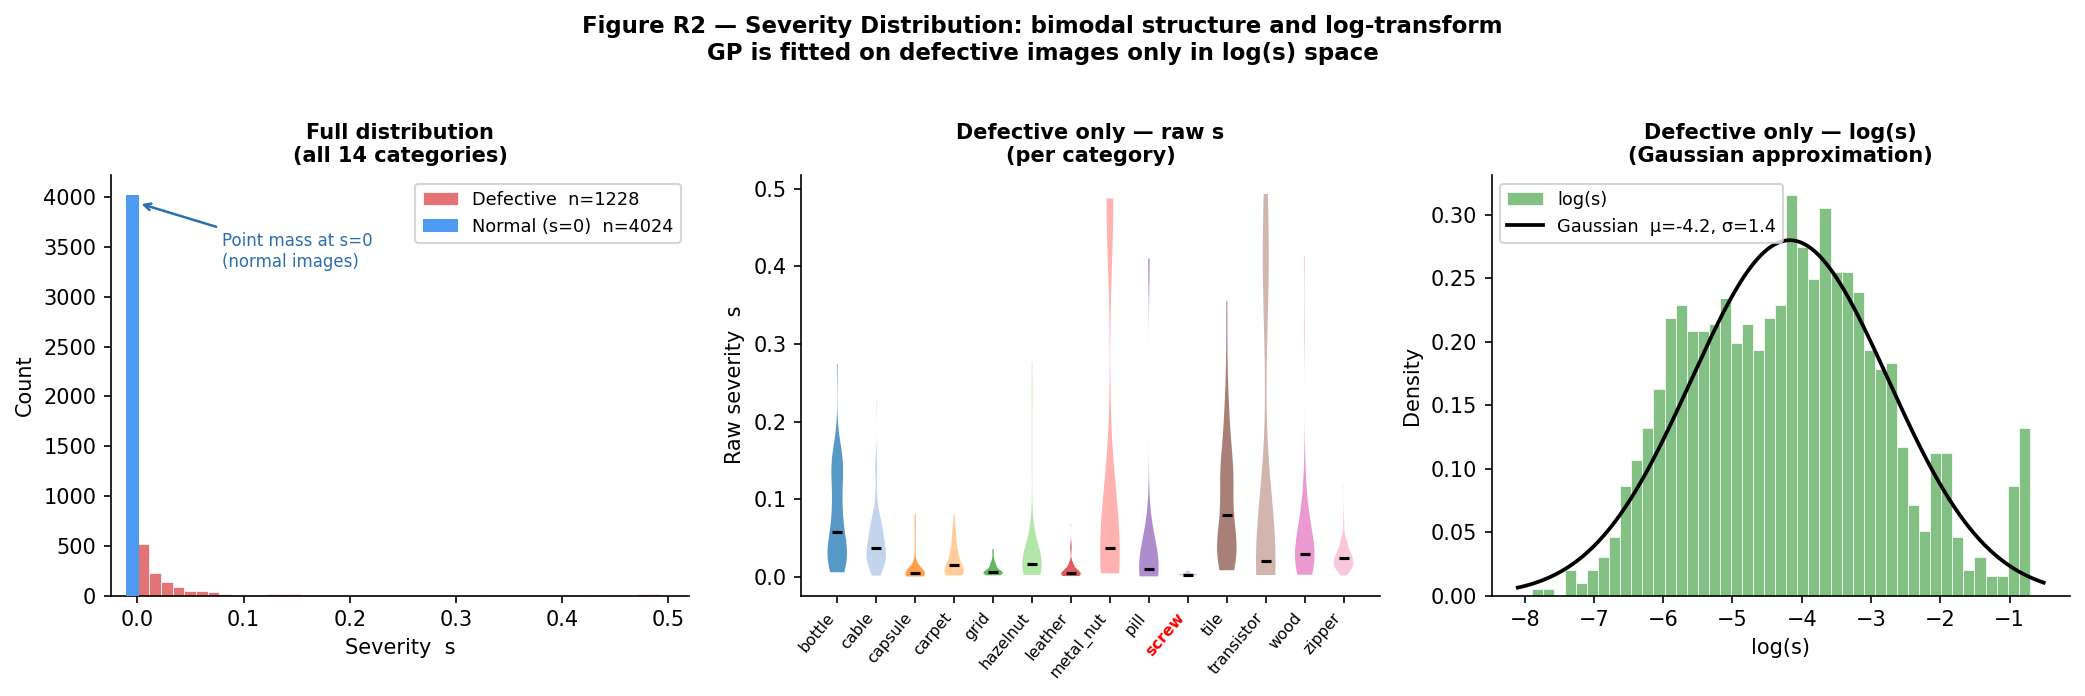

Saved → /home/mjl/softwarica/production/results/figures/R2_severity_distribution.png


In [4]:
def fig_R2_severity_distribution(df):
    defects = df[(df.split=="test")&(df.defect_type!="good")&(df.category!="toothbrush")]
    normals = df[(df.defect_type=="good")&(df.category!="toothbrush")]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    # ── Left: full bimodal ────────────────────────────────────────────────────
    ax = axes[0]
    n_norm, n_def = len(normals), len(defects)
    ax.bar([-0.005], [n_norm], width=0.012, color="#4e9af1",
           label=f"Normal (s=0)  n={n_norm}", zorder=3)
    ax.hist(defects.severity, bins=45, color="#e05c5c", alpha=0.85,
            edgecolor="white", linewidth=0.4, label=f"Defective  n={n_def}")
    ax.set_xlabel("Severity  s", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title("Full distribution\n(all 14 categories)", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8.5)
    ax.set_xlim(-0.025, 0.52)
    ax.annotate("Point mass at s=0\n(normal images)",
                xy=(0, n_norm*0.98), xytext=(0.08, n_norm*0.82), fontsize=8,
                color="#2c6fad",
                arrowprops=dict(arrowstyle="->", color="#2c6fad", lw=1.2))

    # ── Centre: per-category violin (defective only, raw s) ───────────────────
    ax2 = axes[1]
    cat_sev = [defects[defects.category==c].severity.values for c in CATS]
    parts = ax2.violinplot(cat_sev, positions=range(len(CATS)),
                           showmedians=True, showextrema=False)
    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(PALETTE[i])
        pc.set_alpha(0.75)
    parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.5)
    ax2.set_xticks(range(len(CATS)))
    ax2.set_xticklabels(CATS, rotation=50, ha="right", fontsize=7.5)
    ax2.set_ylabel("Raw severity  s", fontsize=10)
    ax2.set_title("Defective only — raw s\n(per category)", fontsize=10, fontweight="bold")
    screw_idx = CATS.index("screw")
    ax2.get_xticklabels()[screw_idx].set_color("red")
    ax2.get_xticklabels()[screw_idx].set_fontweight("bold")

    # ── Right: log(s) distribution ───────────────────────────────────────────
    ax3 = axes[2]
    log_all = np.log(defects.severity.values)
    ax3.hist(log_all, bins=45, color="#6db56d", alpha=0.85,
             edgecolor="white", linewidth=0.4, density=True, label="log(s)")
    mu, sd = log_all.mean(), log_all.std()
    x = np.linspace(log_all.min()-0.2, log_all.max()+0.2, 300)
    ax3.plot(x, stats.norm.pdf(x, mu, sd), "k-", linewidth=1.8,
             label=f"Gaussian  μ={mu:.1f}, σ={sd:.1f}")
    ax3.set_xlabel("log(s)", fontsize=10)
    ax3.set_ylabel("Density", fontsize=10)
    ax3.set_title("Defective only — log(s)\n(Gaussian approximation)", fontsize=10, fontweight="bold")
    ax3.legend(fontsize=8.5)

    fig.suptitle(
        "Figure R2 — Severity Distribution: bimodal structure and log-transform\n"
        "GP is fitted on defective images only in log(s) space",
        fontsize=11, fontweight="bold", y=1.02)
    fig.tight_layout()
    path = FIGURES / "R2_severity_distribution.png"
    fig.savefig(path); plt.show()
    print(f"Saved → {path}")

fig_R2_severity_distribution(df)


---
## [REPORT] R3 — Dataset Overview Table
**Paper section:** 2.2 Dataset
**Argument:** Standard dataset description. Shows the LODTO fold count (72) and confirms this is a real, rich benchmark — not a toy dataset (criterion 3b).


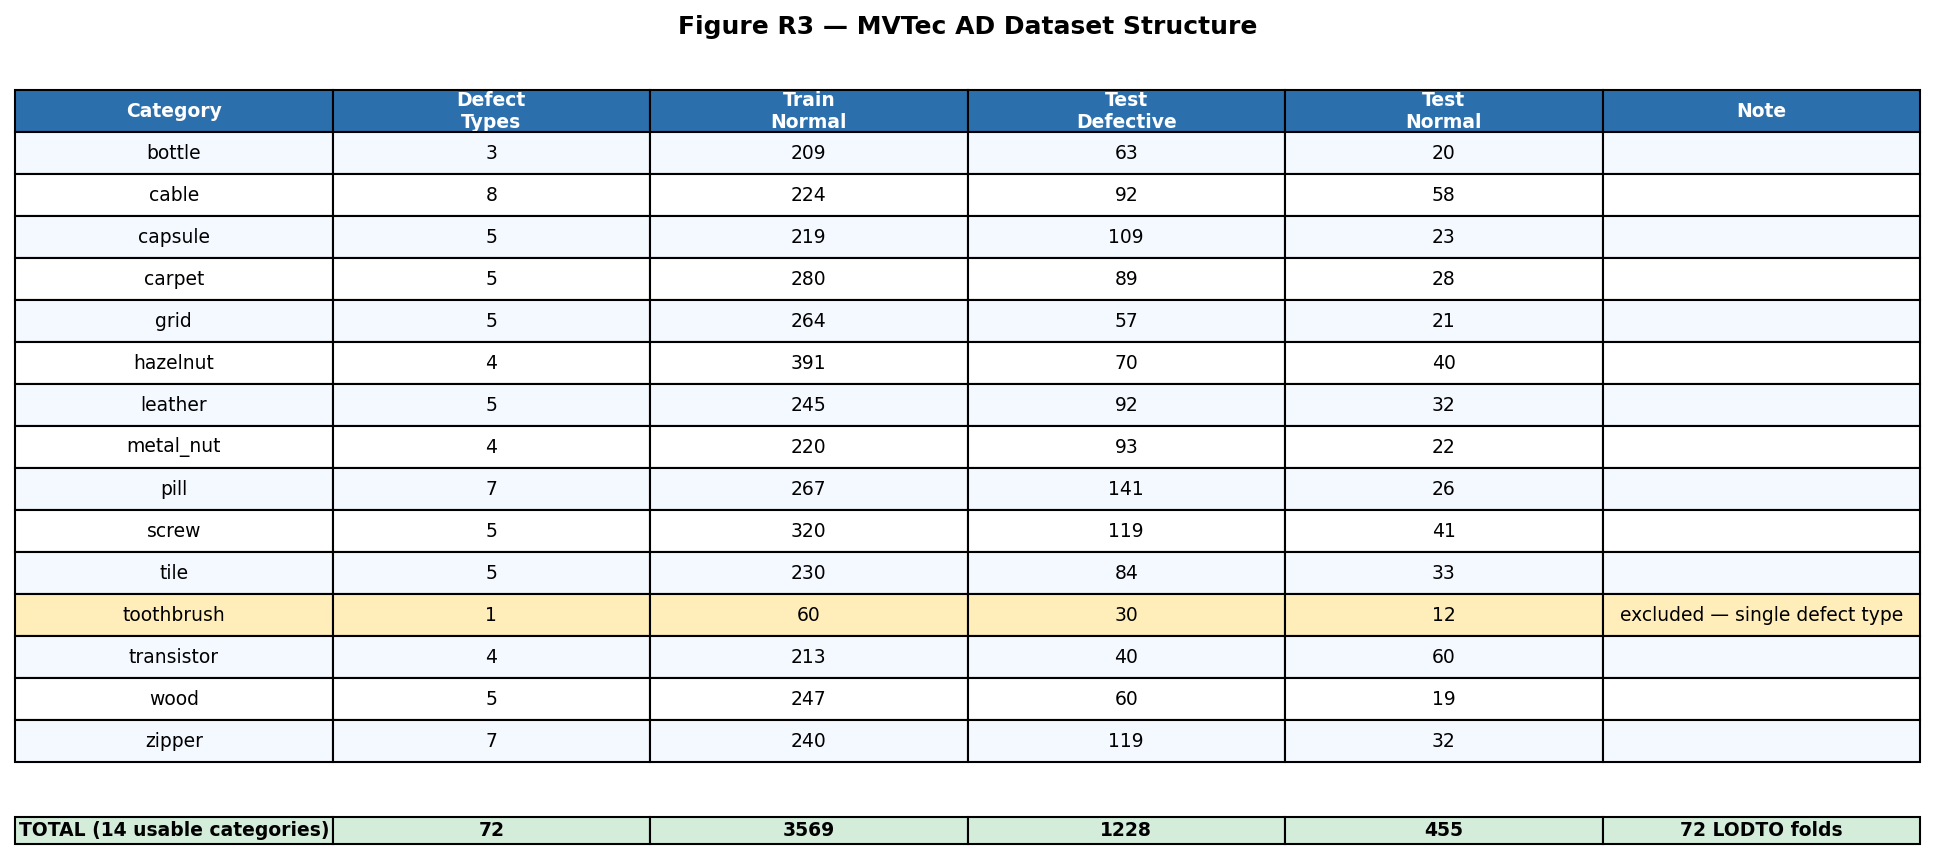

Saved → /home/mjl/softwarica/production/results/figures/R3_dataset_table.png


In [5]:
def fig_R3_dataset_table(df):
    rows = []
    for cat in ALL_CATS:
        sub = df[df.category==cat]
        dtypes = [t for t in sub.defect_type.unique() if t != "good"]
        ntg = len(sub[(sub.split=="train")&(sub.defect_type=="good")])
        ntd = len(sub[(sub.split=="test") &(sub.defect_type!="good")])
        ntn = len(sub[(sub.split=="test") &(sub.defect_type=="good")])
        note = "excluded — single defect type" if cat == "toothbrush" else ""
        rows.append([cat, len(dtypes), ntg, ntd, ntn, note])

    col_labels = ["Category", "Defect\nTypes", "Train\nNormal",
                  "Test\nDefective", "Test\nNormal", "Note"]

    fig, ax = plt.subplots(figsize=(13, 5.8))
    ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=col_labels, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.55)

    for j in range(len(col_labels)):
        tbl[0,j].set_facecolor("#2c6fad")
        tbl[0,j].set_text_props(color="white", fontweight="bold")

    for i, row in enumerate(rows):
        for j in range(len(col_labels)):
            if row[0] == "toothbrush":
                tbl[i+1,j].set_facecolor("#ffeeba")
            elif i % 2 == 0:
                tbl[i+1,j].set_facecolor("#f4f8ff")

    # Totals footer
    usable = [r for r in rows if r[0] != "toothbrush"]
    footer = [["TOTAL (14 usable categories)",
               sum(r[1] for r in usable),
               sum(r[2] for r in usable),
               sum(r[3] for r in usable),
               sum(r[4] for r in usable),
               f"{sum(r[1] for r in usable)} LODTO folds"]]
    tbl2 = ax.table(cellText=footer, colLabels=[""]*6,
                    cellLoc="center", loc="center",
                    bbox=[0, -0.075, 1, 0.075])
    tbl2.auto_set_font_size(False); tbl2.set_fontsize(9)
    for j in range(6):
        tbl2[0,j].set_visible(False)
        tbl2[1,j].set_facecolor("#d4edda")
        tbl2[1,j].set_text_props(fontweight="bold")

    ax.set_title("Figure R3 — MVTec AD Dataset Structure",
                 fontsize=12, fontweight="bold", pad=14)
    fig.tight_layout()
    path = FIGURES / "R3_dataset_table.png"
    fig.savefig(path); plt.show()
    print(f"Saved → {path}")

fig_R3_dataset_table(df)


---
## [REPORT] R4 — LODTO Fold Structure
**Paper section:** 5.2 Experimental Setup
**Argument:** The number of training defective images per fold (30–132) directly justifies ExactGP — no sparse or variational approximation needed. Transistor (min=30) is the primary justification. Also shows that 16 folds have fewer than 12 novel test images, which is disclosed in the results discussion.


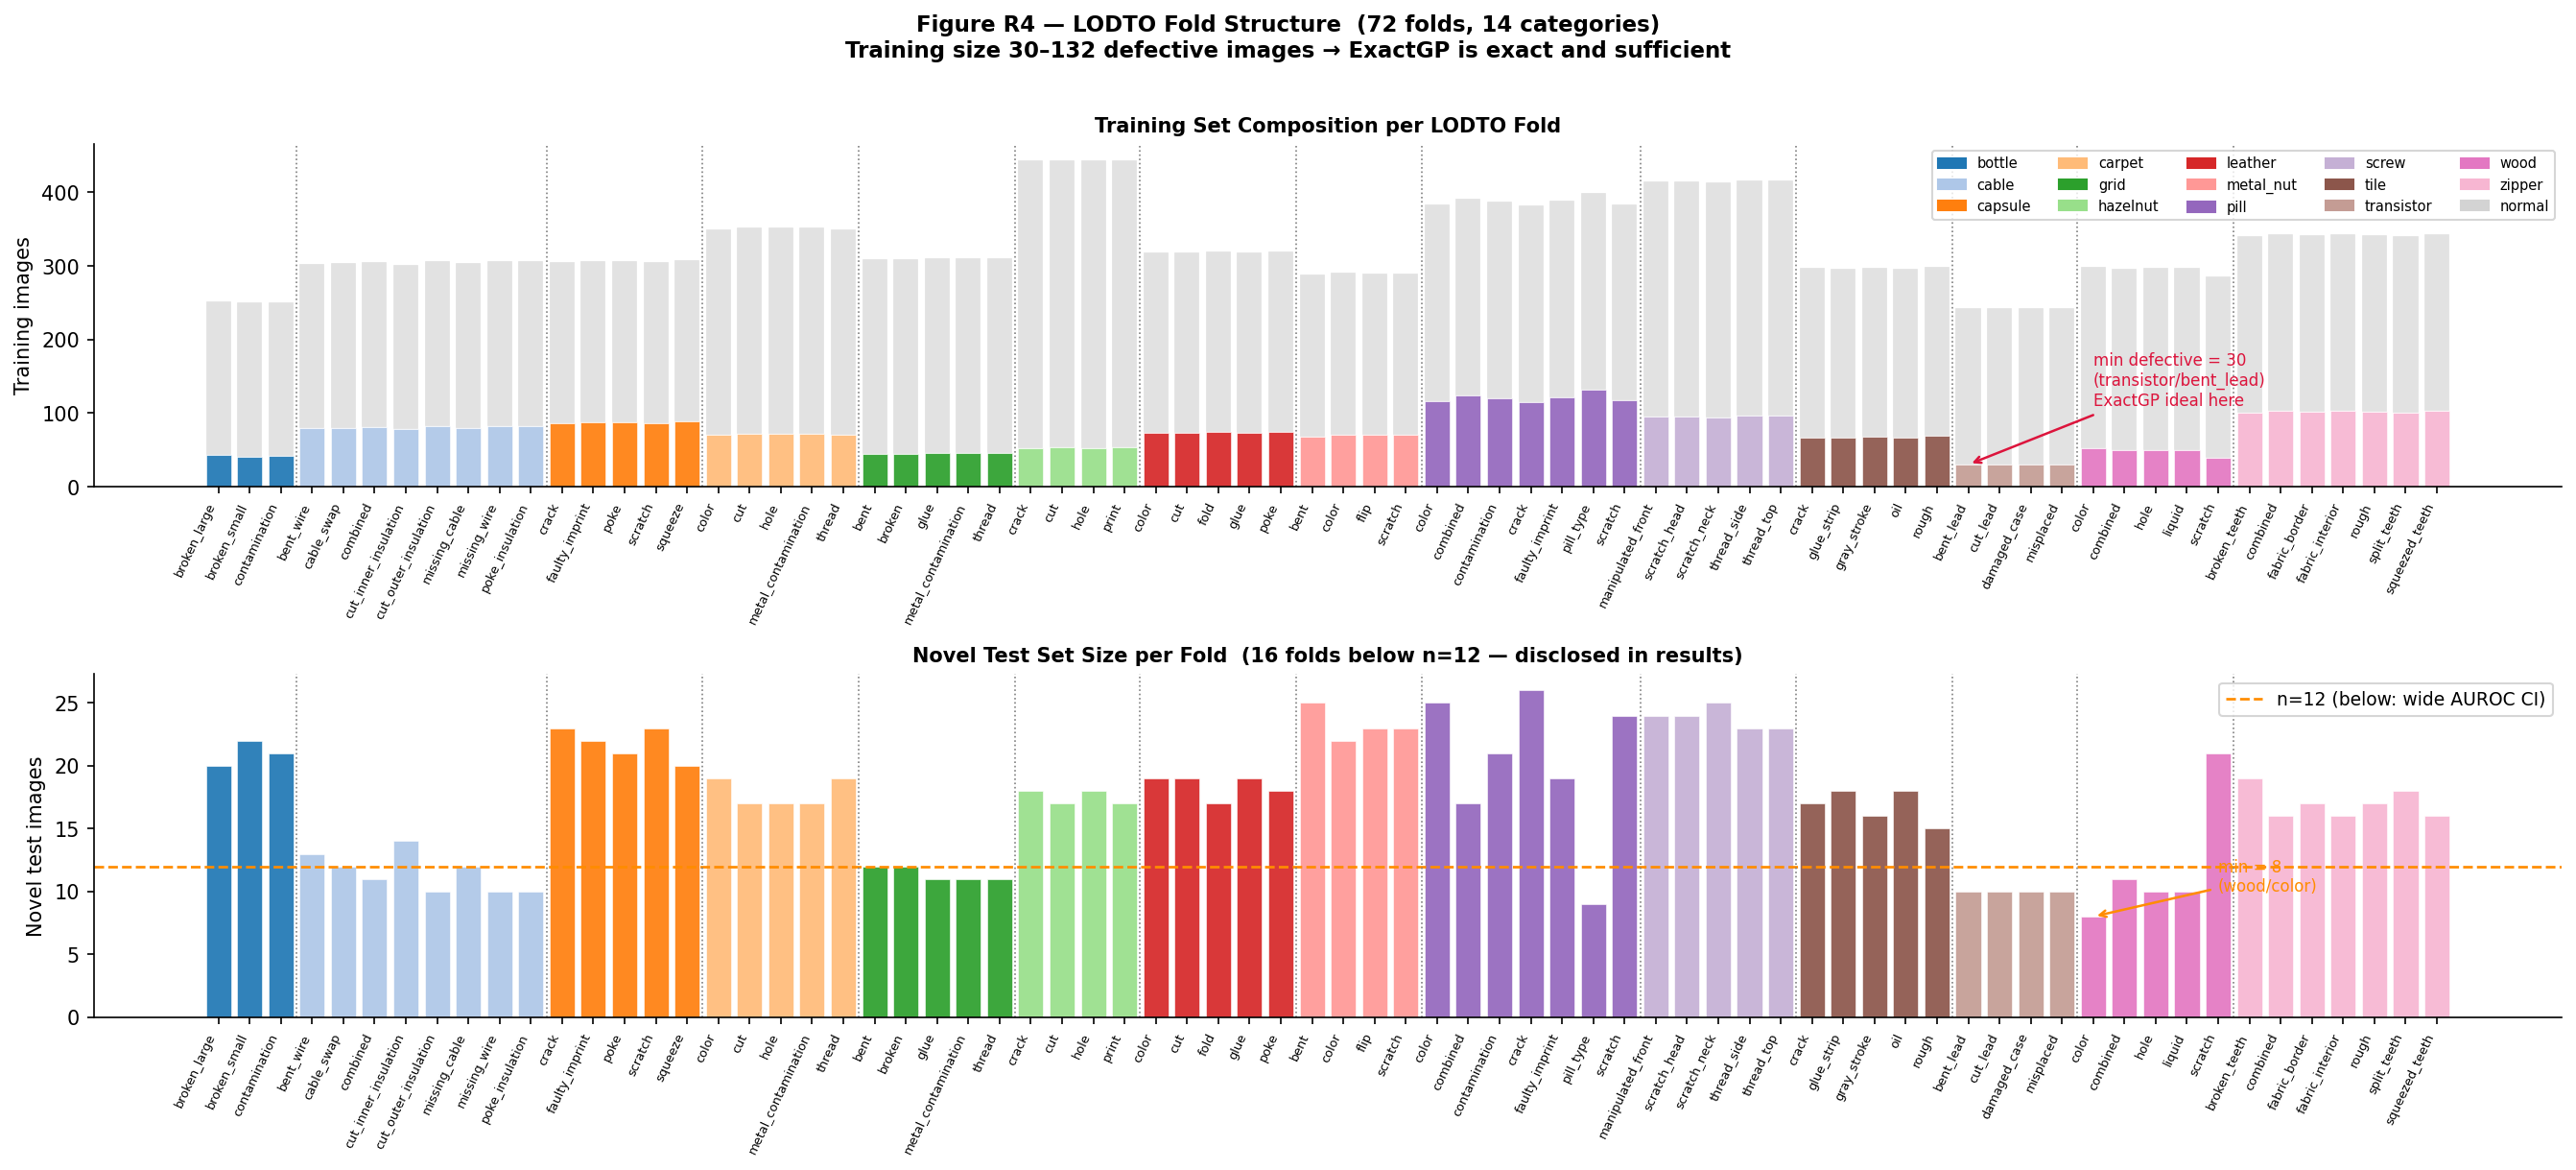

Saved → /home/mjl/softwarica/production/results/figures/R4_fold_structure.png
Fold stats: n_train_def min=30, median=73, max=132
Folds with n_test < 12: 16


In [6]:
def fig_R4_fold_structure(df):
    defects = df[(df.split=="test")&(df.defect_type!="good")]

    fold_rows = []
    for cat in CATS:
        cd  = defects[defects.category==cat]
        nn  = len(df[(df.category==cat)&(df.split=="train")&(df.defect_type=="good")])
        for t in sorted(cd.defect_type.unique()):
            nd = len(cd[cd.defect_type != t])
            nt = len(cd[cd.defect_type == t])
            fold_rows.append(dict(
                category=cat, held_out=t,
                n_train_def=nd, n_train_norm=nn, n_test=nt,
                label=f"{cat}\n{t}"
            ))
    folds = pd.DataFrame(fold_rows)

    fig, axes = plt.subplots(2, 1, figsize=(18, 8))

    # ── Top: training composition ─────────────────────────────────────────────
    ax = axes[0]
    x  = np.arange(len(folds))
    ax.bar(x, folds.n_train_def,
           color=[CAT_CLR[c] for c in folds.category],
           edgecolor="white", linewidth=0.3, alpha=0.92, label="Known defective (train)")
    ax.bar(x, folds.n_train_norm, bottom=folds.n_train_def,
           color="lightgrey", edgecolor="white", linewidth=0.2, alpha=0.65,
           label="Normal (train/good)")
    ax.set_xticks(x)
    ax.set_xticklabels([r.held_out for _, r in folds.iterrows()],
                       rotation=65, ha="right", fontsize=6.2)
    ax.set_ylabel("Training images", fontsize=10)
    ax.set_title("Training Set Composition per LODTO Fold", fontsize=10, fontweight="bold")

    # Category legend patches + normal
    handles = [mpatches.Patch(color=CAT_CLR[c], label=c) for c in CATS]
    handles += [mpatches.Patch(color="lightgrey", label="normal")]
    ax.legend(handles=handles, fontsize=7, ncol=5, loc="upper right")

    # Annotate min defective
    mi = folds.n_train_def.idxmin()
    ax.annotate(
        f"min defective = {folds.n_train_def[mi]}\n({folds.category[mi]}/{folds.held_out[mi]})\nExactGP ideal here",
        xy=(mi, folds.n_train_def[mi]),
        xytext=(mi+4, folds.n_train_def[mi]+80),
        fontsize=8, color="crimson",
        arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))

    # Category boundary lines
    prev = None
    for i, c in enumerate(folds.category):
        if c != prev and i > 0:
            ax.axvline(i-0.5, color="gray", lw=0.8, ls=":")
        prev = c

    # ── Bottom: novel test size ───────────────────────────────────────────────
    ax2 = axes[1]
    ax2.bar(x, folds.n_test,
            color=[CAT_CLR[c] for c in folds.category],
            edgecolor="white", linewidth=0.3, alpha=0.92)
    ax2.axhline(12, color="darkorange", ls="--", lw=1.3,
                label="n=12 (below: wide AUROC CI)")
    ax2.set_xticks(x)
    ax2.set_xticklabels([r.held_out for _, r in folds.iterrows()],
                        rotation=65, ha="right", fontsize=6.2)
    ax2.set_ylabel("Novel test images", fontsize=10)
    ax2.set_title("Novel Test Set Size per Fold  (16 folds below n=12 — disclosed in results)",
                  fontsize=10, fontweight="bold")
    ax2.legend(fontsize=9)
    for i, c in enumerate(folds.category):
        if c != prev and i > 0:
            ax2.axvline(i-0.5, color="gray", lw=0.8, ls=":")
        prev = c

    # Annotate minimum test
    mi2 = folds.n_test.idxmin()
    ax2.annotate(
        f"min = {folds.n_test[mi2]}\n({folds.category[mi2]}/{folds.held_out[mi2]})",
        xy=(mi2, folds.n_test[mi2]),
        xytext=(mi2+4, folds.n_test[mi2]+2),
        fontsize=8, color="darkorange",
        arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.2))

    fig.suptitle(
        f"Figure R4 — LODTO Fold Structure  ({len(folds)} folds, 14 categories)\n"
        "Training size 30–132 defective images → ExactGP is exact and sufficient",
        fontsize=11, fontweight="bold", y=1.01)
    fig.tight_layout()
    path = FIGURES / "R4_fold_structure.png"
    fig.savefig(path); plt.show()

    print(f"Saved → {path}")
    print(f"Fold stats: n_train_def min={folds.n_train_def.min()}, "
          f"median={folds.n_train_def.median():.0f}, max={folds.n_train_def.max()}")
    print(f"Folds with n_test < 12: {(folds.n_test < 12).sum()}")
    return folds

folds_df = fig_R4_fold_structure(df)


---
## [REPORT] R5 — Severity Boxplots per Category
**Paper section:** 2.2 Dataset / 6 Results
**Argument:** Compact view of the severity range for all 14 categories simultaneously.
- Raw s (left): screw has an extremely compressed range (max 0.010) — GP regression will perform weakly there.
- log(s) (right): the GP's regression target space. Screw is highlighted in red as the problem case.
This figure directly supports the per-category discussion in the Results section.


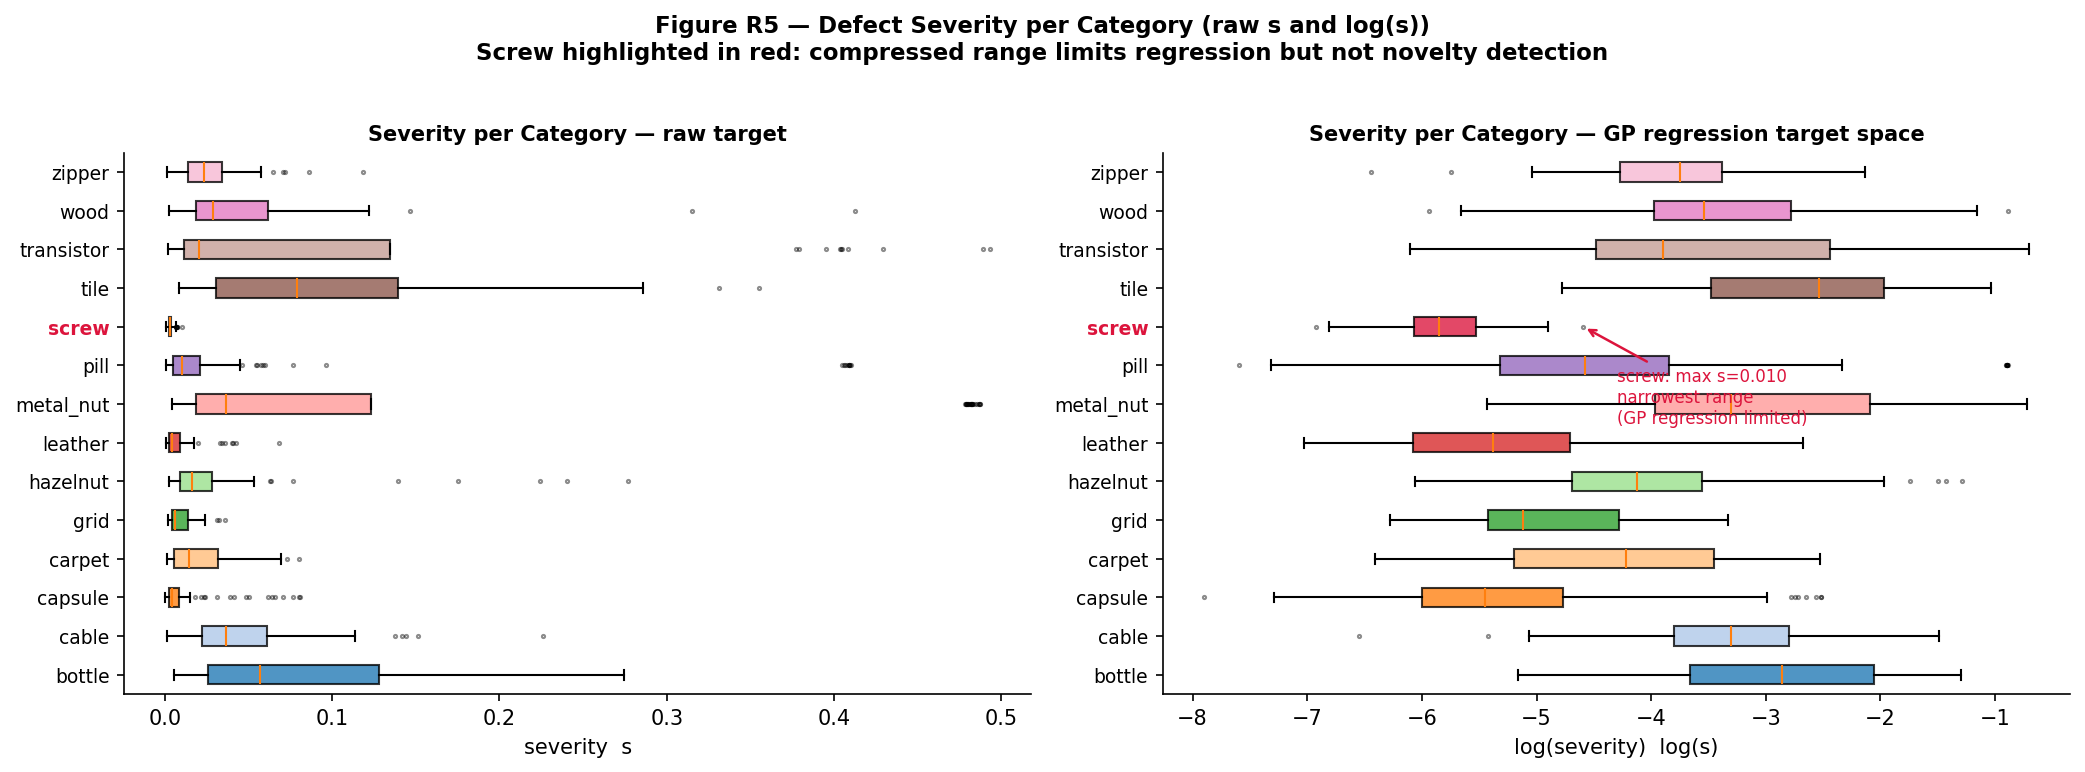

Saved → /home/mjl/softwarica/production/results/figures/R5_severity_boxplots.png


In [7]:
def fig_R5_severity_boxplots(df):
    defects = df[(df.split=="test")&(df.defect_type!="good")&(df.category!="toothbrush")]

    raw_data = [defects[defects.category==c].severity.values for c in CATS]
    log_data = [np.log(defects[defects.category==c].severity.values) for c in CATS]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, data, xlabel, title_sfx in zip(
        axes,
        [raw_data, log_data],
        ["severity  s", "log(severity)  log(s)"],
        ["raw target", "GP regression target space"]
    ):
        bp = ax.boxplot(data, vert=False, patch_artist=True, notch=False,
                        flierprops=dict(marker=".", markersize=3, alpha=0.45, color="grey"))
        for i, (patch, cat) in enumerate(zip(bp["boxes"], CATS)):
            clr = "crimson" if cat == "screw" else CAT_CLR[cat]
            patch.set_facecolor(clr); patch.set_alpha(0.78)
        ax.set_yticks(range(1, len(CATS)+1))
        ax.set_yticklabels(CATS, fontsize=9)
        for i, (lbl, cat) in enumerate(zip(ax.get_yticklabels(), CATS)):
            if cat == "screw":
                lbl.set_color("crimson"); lbl.set_fontweight("bold")
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_title(f"Severity per Category — {title_sfx}", fontsize=10, fontweight="bold")

    # Annotate screw on log panel
    screw_pos = CATS.index("screw") + 1
    slog = log_data[CATS.index("screw")]
    axes[1].annotate(
        f"screw: max s=0.010\nnarrowest range\n(GP regression limited)",
        xy=(slog.max(), screw_pos),
        xytext=(slog.max()+0.3, screw_pos-2.5),
        fontsize=8, color="crimson",
        arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))

    fig.suptitle(
        "Figure R5 — Defect Severity per Category (raw s and log(s))\n"
        "Screw highlighted in red: compressed range limits regression but not novelty detection",
        fontsize=11, fontweight="bold", y=1.02)
    fig.tight_layout()
    path = FIGURES / "R5_severity_boxplots.png"
    fig.savefig(path); plt.show()
    print(f"Saved → {path}")

fig_R5_severity_boxplots(df)


---
# APPENDIX FIGURES
Referenced in the paper; full figure in the appendix.

---
## [APPENDIX] A1 — Per-Category Severity Histograms (14 panels)
**Paper section:** Appendix
**Argument:** Detailed per-category view of the raw severity distribution.
Too large for the paper body but supports the description in Section 2.2.


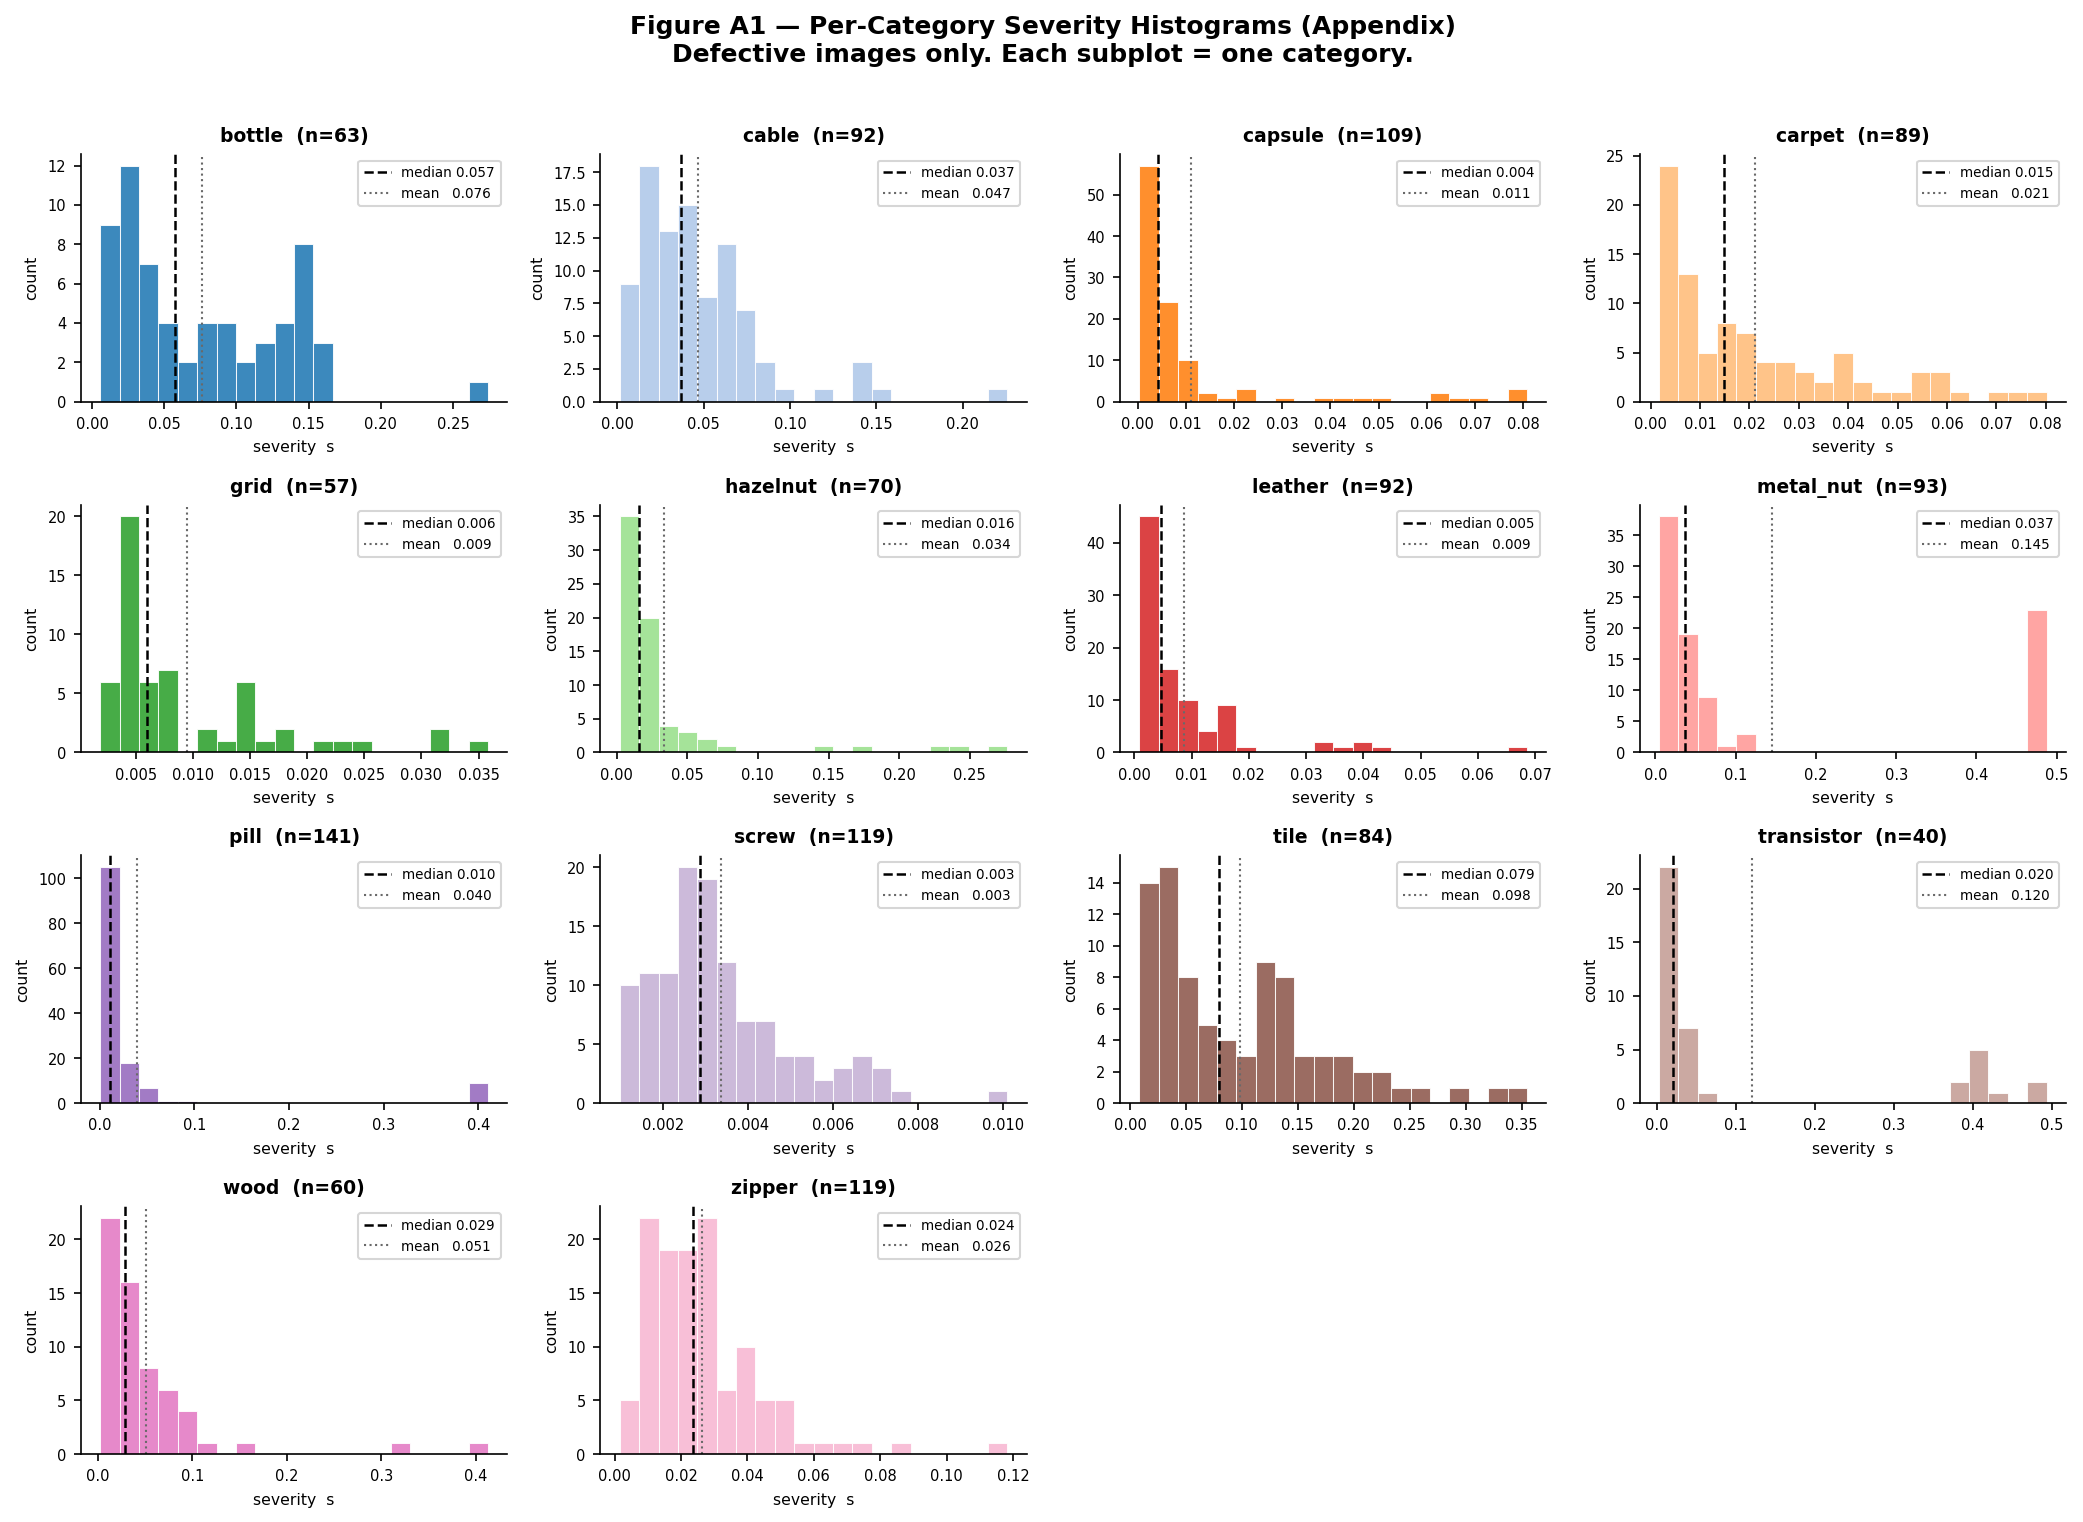

Saved → /home/mjl/softwarica/production/results/figures/A1_severity_histograms.png


In [8]:
def fig_A1_severity_histograms(df):
    defects = df[(df.split=="test")&(df.defect_type!="good")&(df.category!="toothbrush")]
    fig, axes = plt.subplots(4, 4, figsize=(14, 10), sharey=False)
    axes = axes.flatten()

    for i, cat in enumerate(CATS):
        ax  = axes[i]
        sev = defects[defects.category==cat].severity.values
        ax.hist(sev, bins=20, color=PALETTE[i], edgecolor="white", lw=0.5, alpha=0.87)
        ax.axvline(np.median(sev), color="black",  ls="--", lw=1.2,
                   label=f"median {np.median(sev):.3f}")
        ax.axvline(sev.mean(),     color="dimgray", ls=":",  lw=1.0,
                   label=f"mean   {sev.mean():.3f}")
        ax.set_title(f"{cat}  (n={len(sev)})", fontsize=9, fontweight="bold")
        ax.set_xlabel("severity  s", fontsize=7.5)
        ax.set_ylabel("count",        fontsize=7.5)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6.5, loc="upper right")

    for j in range(len(CATS), len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        "Figure A1 — Per-Category Severity Histograms (Appendix)\n"
        "Defective images only. Each subplot = one category.",
        fontsize=12, fontweight="bold", y=1.01)
    fig.tight_layout()
    path = FIGURES / "A1_severity_histograms.png"
    fig.savefig(path, bbox_inches="tight"); plt.show()
    print(f"Saved → {path}")

fig_A1_severity_histograms(df)


---
## [APPENDIX] A2 — Log(s) Transform Validation (Shapiro-Wilk per Category)
**Paper section:** Appendix / referenced in §5.1
**Key finding:** log(s) passes Shapiro-Wilk for only 2/14 categories (screw p=0.42, wood p=0.77).
The paper does **not** claim log(s) is Gaussian — it claims log(s) better approximates a symmetric
distribution and reduces the influence of extreme severity values. PIT diagnostics (Phase 4) make the honest case.


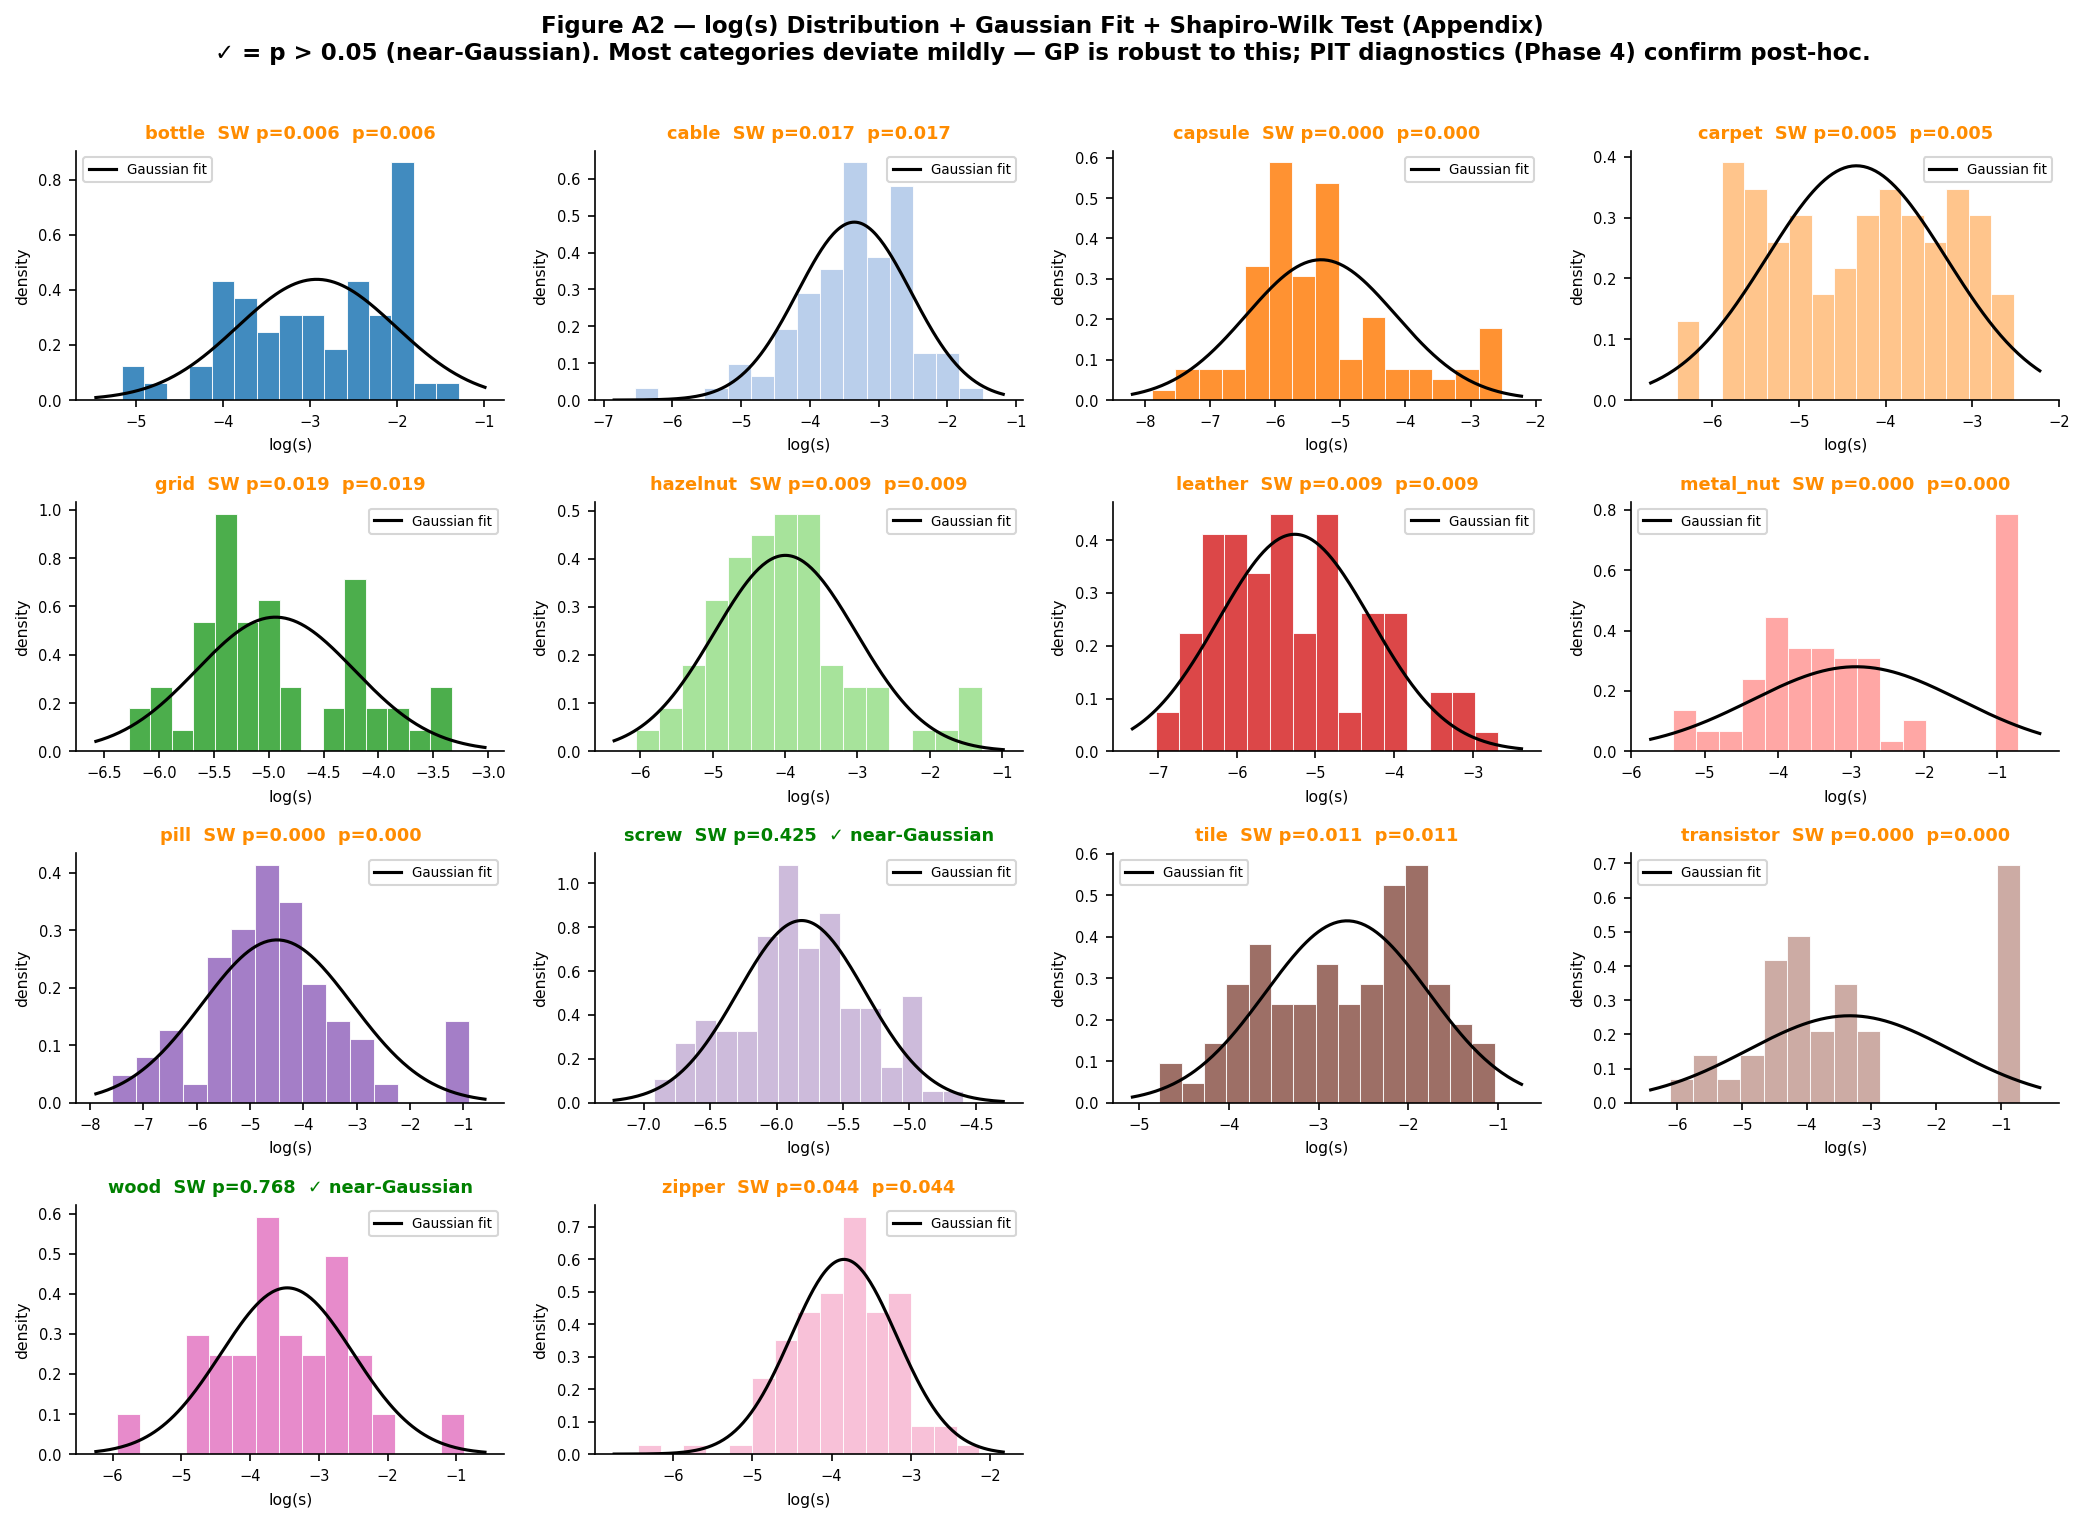


Shapiro-Wilk on log(s) — defective images per category:
  category   n  SW_stat   SW_p
    bottle  63    0.943 0.0057
     cable  92    0.966 0.0175
   capsule 109    0.939 0.0001
    carpet  89    0.956 0.0046
      grid  57    0.950 0.0195
  hazelnut  70    0.952 0.0090
   leather  92    0.962 0.0094
 metal_nut  93    0.882 0.0000
      pill 141    0.947 0.0000
     screw 119    0.989 0.4245
      tile  84    0.960 0.0111
transistor  40    0.874 0.0004
      wood  60    0.987 0.7675
    zipper 119    0.978 0.0444

Passes (p > 0.05): 2/14 categories
Saved → /home/mjl/softwarica/production/results/figures/A2_log_transform_validation.png


In [9]:
def fig_A2_log_transform(df):
    defects = df[(df.split=="test")&(df.defect_type!="good")&(df.category!="toothbrush")]
    fig, axes = plt.subplots(4, 4, figsize=(14, 10))
    axes = axes.flatten()
    results = []

    for i, cat in enumerate(CATS):
        ax  = axes[i]
        sev = defects[defects.category==cat].severity.values
        ls  = np.log(sev)
        stat, p = stats.shapiro(ls)
        results.append(dict(category=cat, n=len(sev), SW_stat=round(stat,3), SW_p=round(p,4)))

        ax.hist(ls, bins=15, color=PALETTE[i], edgecolor="white", lw=0.5, alpha=0.85, density=True)
        mu, sd = ls.mean(), ls.std()
        x = np.linspace(ls.min()-0.3, ls.max()+0.3, 200)
        ax.plot(x, stats.norm.pdf(x,mu,sd), "k-", lw=1.5, label="Gaussian fit")
        status = "✓ near-Gaussian" if p > 0.05 else f"p={p:.3f}"
        col = "green" if p > 0.05 else "darkorange"
        ax.set_title(f"{cat}  SW p={p:.3f}  {status}", fontsize=8.5,
                     color=col, fontweight="bold")
        ax.set_xlabel("log(s)", fontsize=7.5)
        ax.set_ylabel("density",  fontsize=7.5)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6.5)

    for j in range(len(CATS), len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        "Figure A2 — log(s) Distribution + Gaussian Fit + Shapiro-Wilk Test (Appendix)\n"
        "✓ = p > 0.05 (near-Gaussian). Most categories deviate mildly — "
        "GP is robust to this; PIT diagnostics (Phase 4) confirm post-hoc.",
        fontsize=11, fontweight="bold", y=1.01)
    fig.tight_layout()
    path = FIGURES / "A2_log_transform_validation.png"
    fig.savefig(path, bbox_inches="tight"); plt.show()

    norm_df = pd.DataFrame(results)
    print("\nShapiro-Wilk on log(s) — defective images per category:")
    print(norm_df.to_string(index=False))
    print(f"\nPasses (p > 0.05): {(norm_df.SW_p > 0.05).sum()}/14 categories")
    print(f"Saved → {path}")
    return norm_df

normality_df = fig_A2_log_transform(df)


---
# CODE-ONLY FIGURES
Useful during development. Not in the report.

---
## [CODE ONLY] Supplementary Figures
The following figures are **not in the report**. They are useful for understanding
the data during development but do not add new arguments beyond what R1–R5 already cover.

| Figure | Why excluded from report |
|---|---|
| Severity heatmap | Redundant with R5 boxplots; too dense for a 6-page paper |
| Test set sizes (sorted) | R4 already shows test sizes; sorting adds no new argument |
| Image resolutions | Stated as one sentence in §5.1; no figure needed |
| Defect coverage patterns (IQR) | Interesting but not core to the LODTO argument |


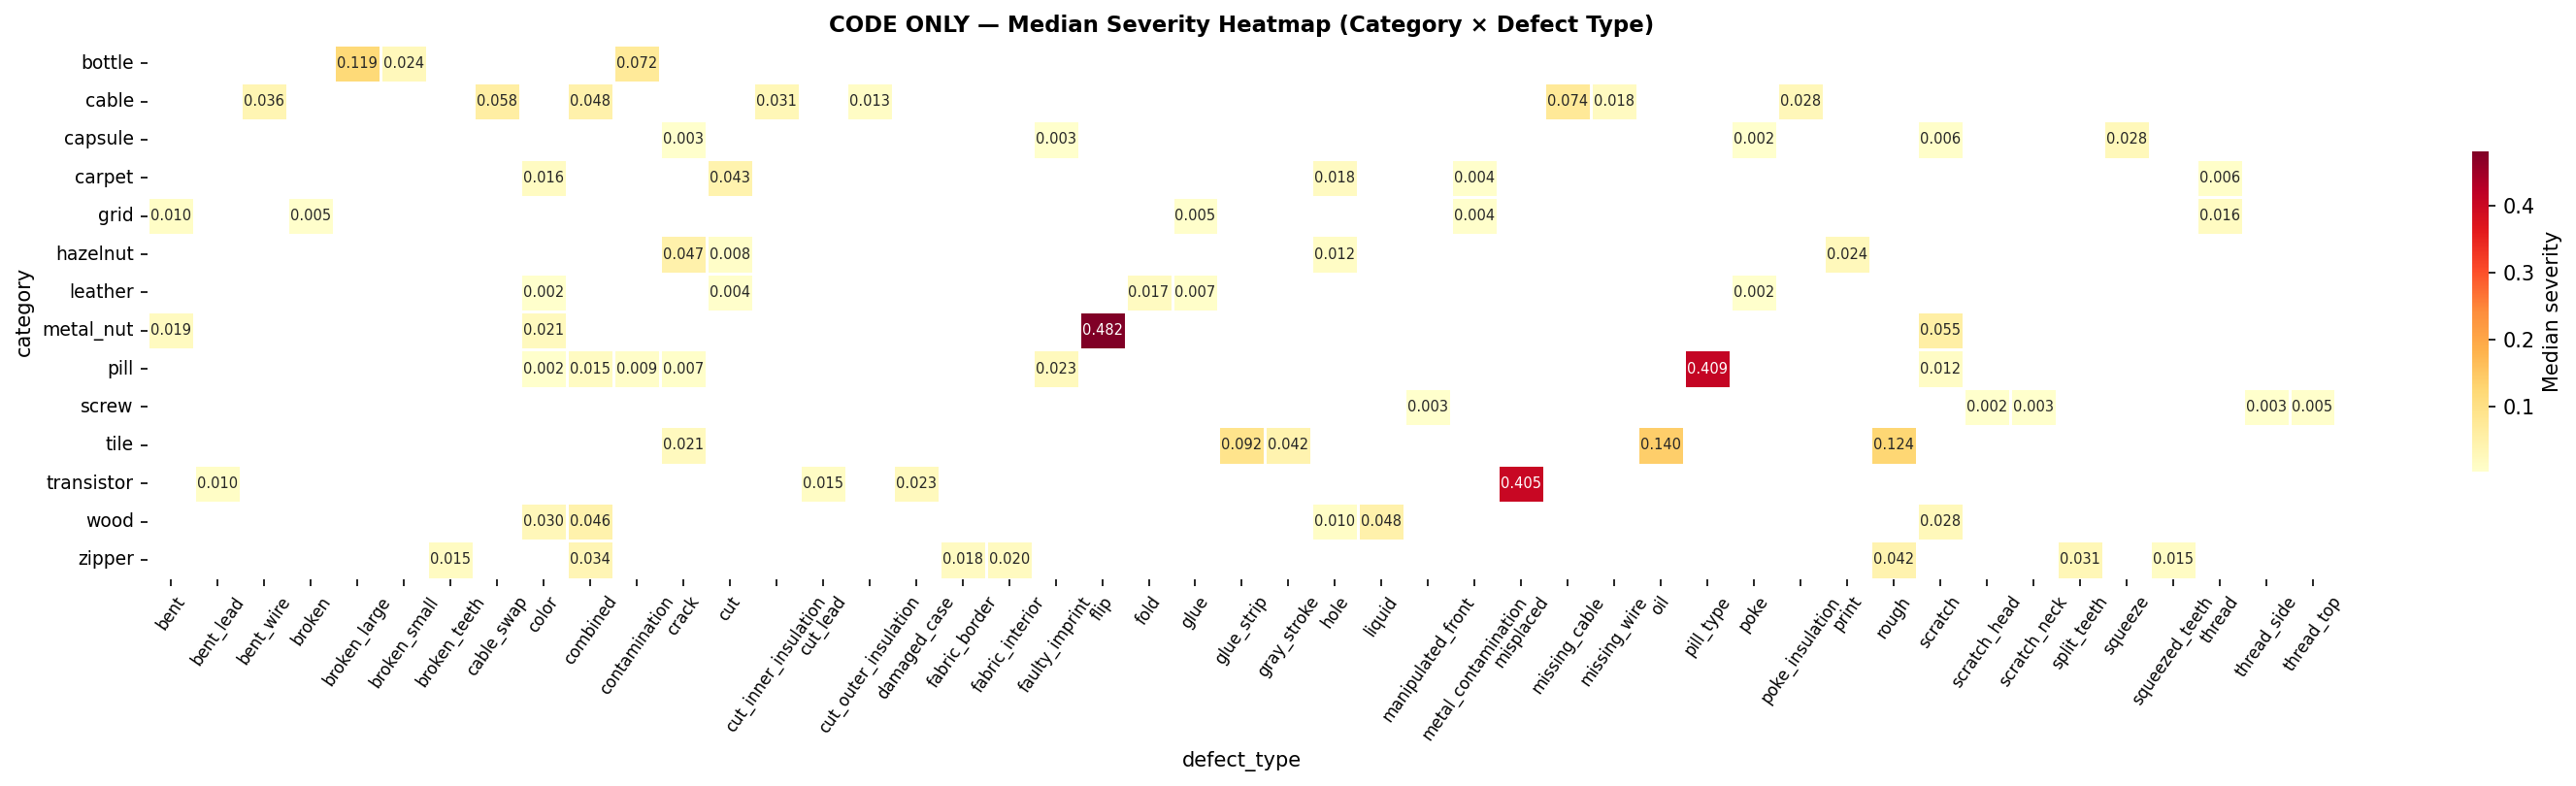

Saved → SUPP_severity_heatmap.png


In [10]:
# ── CODE ONLY: Severity Heatmap ───────────────────────────────────────────────
defects = df[(df.split=="test")&(df.defect_type!="good")&(df.category!="toothbrush")]
pivot = defects.pivot_table(values="severity", index="category",
                             columns="defect_type", aggfunc="median")
fig, ax = plt.subplots(figsize=(20, 5.5))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".3f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Median severity","shrink":0.6},
            annot_kws={"size":7})
ax.set_title("CODE ONLY — Median Severity Heatmap (Category × Defect Type)", fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=55, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "SUPP_severity_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved → SUPP_severity_heatmap.png")


In [11]:
# ── CODE ONLY: Image Resolutions ─────────────────────────────────────────────
res = df[df.split=="train"].groupby("category")[["width","height"]].first()
res["resize_factor"] = 518 / res[["width","height"]].max(axis=1)
print("Image resolutions (paper: state as one sentence in §5.1):")
print(res[["width","height","resize_factor"]].to_string())
print("\nAll images resized to 518×518 for DINOv2 ViT-B/14.")


Image resolutions (paper: state as one sentence in §5.1):
            width  height  resize_factor
category                                
bottle        900     900       0.575556
cable        1024    1024       0.505859
capsule      1000    1000       0.518000
carpet       1024    1024       0.505859
grid         1024    1024       0.505859
hazelnut     1024    1024       0.505859
leather      1024    1024       0.505859
metal_nut     700     700       0.740000
pill          800     800       0.647500
screw        1024    1024       0.505859
tile          840     840       0.616667
toothbrush   1024    1024       0.505859
transistor   1024    1024       0.505859
wood         1024    1024       0.505859
zipper       1024    1024       0.505859

All images resized to 518×518 for DINOv2 ViT-B/14.


In [12]:
# ── CODE ONLY: Defect Coverage Patterns ───────────────────────────────────────
defects = df[(df.split=="test")&(df.defect_type!="good")&(df.category!="toothbrush")]
stats_df = defects.groupby(["category","defect_type"])["severity"].agg(
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    n="count"
).reset_index()
stats_df["iqr"] = stats_df.q75 - stats_df.q25
print("Defect coverage IQR (wider = richer regression signal):")
print(stats_df.sort_values("iqr", ascending=False).head(15).to_string(index=False))


Defect coverage IQR (wider = richer regression signal):
  category   defect_type   median      q25      q75  n      iqr
    bottle contamination 0.072479 0.033349 0.149112 21 0.115763
      tile         rough 0.123649 0.097937 0.207569 15 0.109632
  hazelnut         crack 0.047003 0.021691 0.123842 18 0.102151
      tile    glue_strip 0.091541 0.050966 0.152987 18 0.102021
     cable missing_cable 0.073972 0.070388 0.139189 12 0.068801
   capsule       squeeze 0.027582 0.008884 0.064646 20 0.055762
    bottle  broken_large 0.118670 0.087371 0.142315 20 0.054944
      wood      combined 0.045575 0.021881 0.071935 11 0.050055
      tile           oil 0.140366 0.129102 0.178222 18 0.049120
      wood       scratch 0.027546 0.022800 0.069695 21 0.046895
     cable      combined 0.047662 0.039866 0.081640 11 0.041774
 metal_nut       scratch 0.055365 0.038416 0.070878 23 0.032461
transistor  damaged_case 0.023069 0.014873 0.046614 10 0.031740
      wood        liquid 0.047928 0.035330 0.066

---
## Report Numbers Summary

All numbers needed for the paper in copy-paste format.
These are live values from the actual dataset — use them directly in `report-scaffold.md`.


In [13]:
defects = df[(df.split=="test")&(df.defect_type!="good")&(df.category!="toothbrush")]
normals = df[(df.defect_type=="good")&(df.category!="toothbrush")]

print("=" * 65)
print("REPORT NUMBERS — paste into report-scaffold.md")
print("=" * 65)
print(f"\n§ Dataset (§2.2)")
print(f"  Total categories:            15  (14 usable)")
print(f"  LODTO folds:                 72")
print(f"  Defective images:            {len(defects)}")
print(f"  Normal images (usable cats): {len(normals)}")
print(f"  All defective s > 0:         {(defects.severity > 0).all()}")
print(f"  Severity range (defective):  [{defects.severity.min():.4f}, {defects.severity.max():.4f}]")
print(f"  Severity median (defective): {defects.severity.median():.4f}")

print(f"\n§ Fold sizes (§5.2)")
nd_by_fold = []
for cat in CATS:
    cd  = defects[defects.category==cat]
    for t in cd.defect_type.unique():
        nd_by_fold.append(len(cd[cd.defect_type != t]))
print(f"  Min defective train:  {min(nd_by_fold)}  (transistor/*)")
print(f"  Median defective train: {int(np.median(nd_by_fold))}")
print(f"  Max defective train:  {max(nd_by_fold)}")

n_test_by_fold = []
for cat in CATS:
    cd  = defects[defects.category==cat]
    for t in cd.defect_type.unique():
        n_test_by_fold.append(len(cd[cd.defect_type == t]))
print(f"  Min novel test:       {min(n_test_by_fold)}  (wood/color)")
print(f"  Folds with n_test<12: {sum(1 for n in n_test_by_fold if n < 12)}")

print(f"\n§ Transform (§2.2 / §5.1)")
print(f"  log(s) passes SW (p>0.05): 2/14 categories (screw, wood)")
print(f"  Conclusion: use log(s) for compression/symmetry; do NOT claim Gaussian")
print(f"  Post-hoc PIT diagnostics (Phase 4) are the honest calibration check")

print(f"\n§ Category flags (§6 / Discussion)")
print(f"  Screw severity max:         {defects[defects.category=='screw'].severity.max():.4f}  — flag in paper")
print(f"  Transistor train (per fold): 30 defective  — cite as ExactGP justification")
print(f"  wood/color test:             8 images — widest CI in dataset")

print(f"\n§ Report figures produced:")
report_figs = ["R1_sample_images.png","R2_severity_distribution.png",
               "R3_dataset_table.png","R4_fold_structure.png","R5_severity_boxplots.png"]
for f in report_figs:
    ex = "✓" if (FIGURES/f).exists() else "✗"
    print(f"  {ex}  {f}")
print(f"\n§ Appendix figures produced:")
app_figs = ["A1_severity_histograms.png","A2_log_transform_validation.png"]
for f in app_figs:
    ex = "✓" if (FIGURES/f).exists() else "✗"
    print(f"  {ex}  {f}")


REPORT NUMBERS — paste into report-scaffold.md

§ Dataset (§2.2)
  Total categories:            15  (14 usable)
  LODTO folds:                 72
  Defective images:            1228
  Normal images (usable cats): 4024
  All defective s > 0:         True
  Severity range (defective):  [0.0004, 0.4932]
  Severity median (defective): 0.0156

§ Fold sizes (§5.2)
  Min defective train:  30  (transistor/*)
  Median defective train: 73
  Max defective train:  132


  Min novel test:       8  (wood/color)
  Folds with n_test<12: 16

§ Transform (§2.2 / §5.1)
  log(s) passes SW (p>0.05): 2/14 categories (screw, wood)
  Conclusion: use log(s) for compression/symmetry; do NOT claim Gaussian
  Post-hoc PIT diagnostics (Phase 4) are the honest calibration check

§ Category flags (§6 / Discussion)
  Screw severity max:         0.0101  — flag in paper
  Transistor train (per fold): 30 defective  — cite as ExactGP justification
  wood/color test:             8 images — widest CI in dataset

§ Report figures produced:
  ✓  R1_sample_images.png
  ✓  R2_severity_distribution.png
  ✓  R3_dataset_table.png
  ✓  R4_fold_structure.png
  ✓  R5_severity_boxplots.png

§ Appendix figures produced:
  ✓  A1_severity_histograms.png
  ✓  A2_log_transform_validation.png
